<a href="https://colab.research.google.com/github/Andalejo1109/retornos-diarios/blob/main/Dias_positivos%2Bnegativos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [20]:
# 1. Definir los activos y sus pesos en el portafolio
tickers = ['SPYG', 'SMH', 'IEMG', 'VTI', 'BRK-B']
pesos = [0.35, 0.2, 0.15, 0.08, 0.22]

# 2. Descargar datos de un período histórico (por ejemplo, 2022)
print("Descargando datos del mercado...")
datos = yf.download(tickers, start="2026-01-01", end="2026-08-07", auto_adjust=False)['Adj Close']

# 3. Calcular el rendimiento diario del portafolio
retornos_activos = datos.pct_change().dropna()
retornos_diarios = (retornos_activos * pesos).sum(axis=1)

# 4. Clasificar días positivos y negativos
dias_positivos = (retornos_diarios > 0).sum()
dias_negativos = (retornos_diarios < 0).sum()
dias_neutros = (retornos_diarios == 0).sum()

# 5. Calcular Acumulado Mensual
acumulado_mensual = retornos_diarios.resample('ME').apply(lambda x: (1 + x).prod() - 1)

[*********************100%***********************]  5 of 5 completed

Descargando datos del mercado...


In [21]:
# 6. Calcular YTD (Year-to-Date) diario
ytd_diario = (1 + retornos_diarios).cumprod() - 1
ytd_actual = ytd_diario.iloc[-1]

# --- Impresión de Resultados en Consola ---
print("\n" + "="*40)
print(" RESUMEN DEL PORTAFOLIO 2026")
print("="*40)
print(f" Días Positivos: {dias_positivos}")
print(f" Días Negativos: {dias_negativos}")
print(f" Días Neutros: {dias_neutros}")
print(f" YTD Actual: {ytd_actual:.2%}")
print("="*40)



 RESUMEN DEL PORTAFOLIO 2026
 Días Positivos: 82
 Días Negativos: 66
 Días Neutros: 0
 YTD Actual: 17.52%


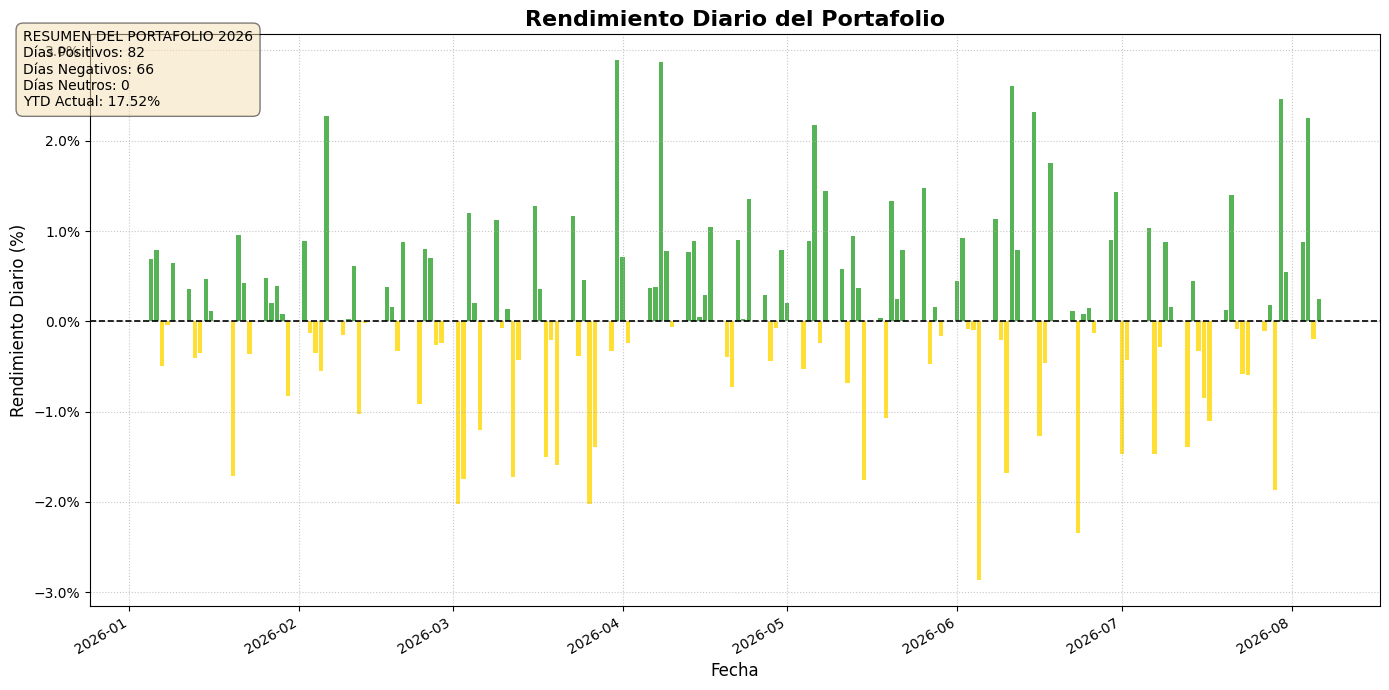

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 7. Generar el Gráfico de Rendimientos Diarios (Verde y Amarillo)

# Crear la figura y el subgráfico
fig_daily, ax_daily = plt.subplots(figsize=(14, 7))

# Definir colores para días positivos y negativos
colores_diarios = ['#2ca02c' if val > 0 else '#ffd700' for val in retornos_diarios] # Green for positive, yellow for negative

# Crear el gráfico de barras para los rendimientos diarios
ax_daily.bar(retornos_diarios.index, retornos_diarios * 100, color=colores_diarios, width=0.8, alpha=0.8)
ax_daily.axhline(0, color='black', linestyle='--', linewidth=1.2) # Línea base en 0%

# Configurar el título y las etiquetas
ax_daily.set_title('Rendimiento Diario del Portafolio', fontsize=16, fontweight='bold')
ax_daily.set_xlabel('Fecha', fontsize=12)
ax_daily.set_ylabel('Rendimiento Diario (%)', fontsize=12)

# Formatear el eje Y como porcentaje
ax_daily.yaxis.set_major_formatter(mtick.PercentFormatter())

# Añadir cuadrícula para mejor lectura
ax_daily.grid(True, linestyle=':', alpha=0.7)

# Mejorar el formato de las fechas en el eje X si hay muchas fechas
fig_daily.autofmt_xdate()

# Add the summary text to the figure
summary_text = (
    "RESUMEN DEL PORTAFOLIO 2026\n"  # Adjusted title
    f"Días Positivos: {dias_positivos}\n"
    f"Días Negativos: {dias_negativos}\n"
    f"Días Neutros: {dias_neutros}\n"
    f"YTD Actual: {ytd_actual:.2%}"
)
fig_daily.text(0.02, 0.95, summary_text, transform=fig_daily.transFigure, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

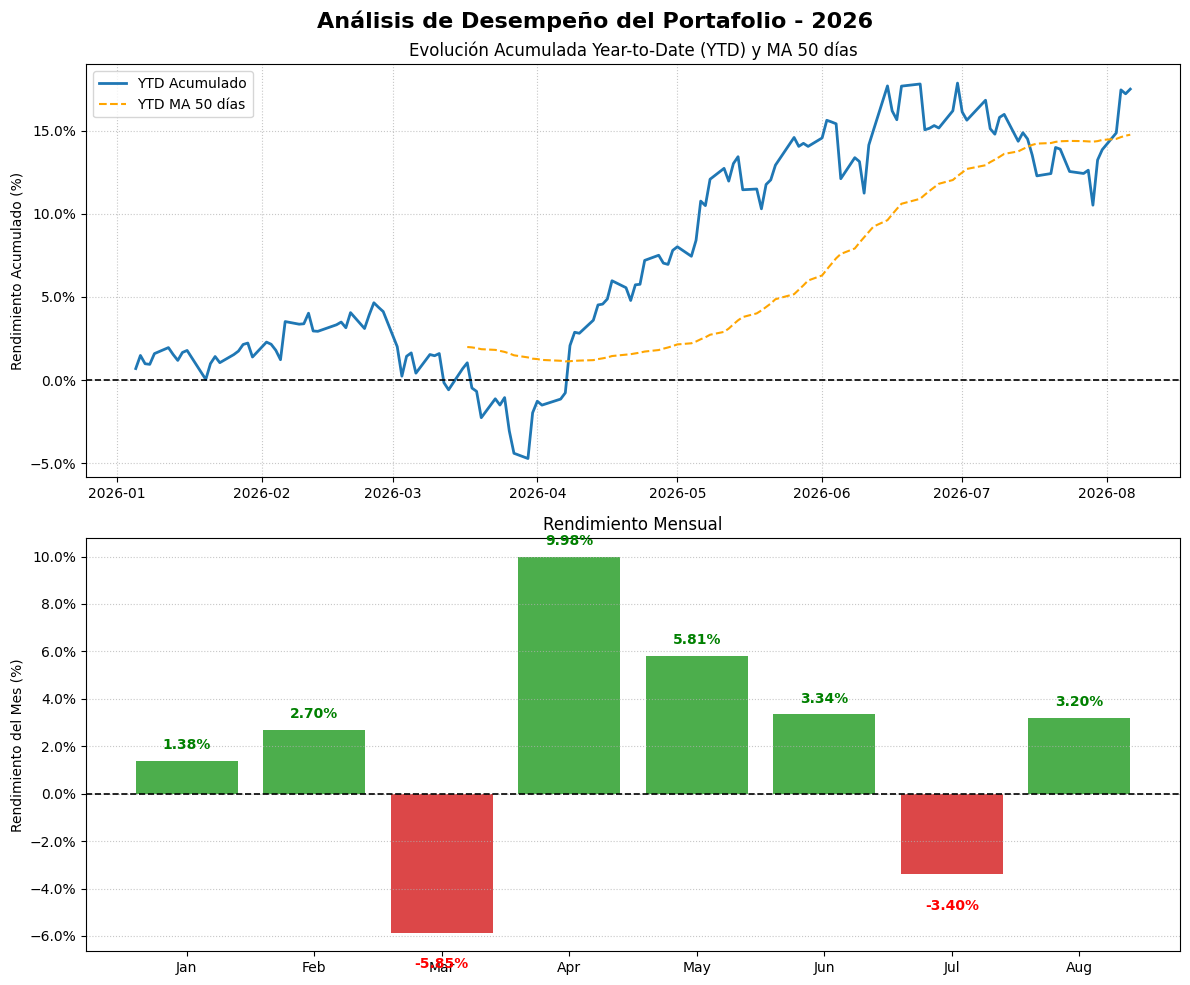

In [23]:
# --- 8. Generación del Gráfico con Matplotlib ---

# Crear la figura con 2 subgráficos (2 filas, 1 columna)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Análisis de Desempeño del Portafolio - 2026', fontsize=16, fontweight='bold')

# Calcular el 50-día promedio móvil del YTD diario
ytd_diario_ma50 = ytd_diario.rolling(window=50).mean()

# Subgráfico 1: Evolución YTD (Línea)
ax1.plot(ytd_diario.index, ytd_diario * 100, color='#1f77b4', linewidth=2, label='YTD Acumulado')
ax1.plot(ytd_diario_ma50.index, ytd_diario_ma50 * 100, color='orange', linestyle='--', linewidth=1.5, label='YTD MA 50 días')
ax1.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax1.set_title('Evolución Acumulada Year-to-Date (YTD) y MA 50 días', fontsize=12)
ax1.set_ylabel('Rendimiento Acumulado (%)')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# Subgráfico 2: Rendimiento Mensual (Barras)
# Crear lista de colores: verde si > 0, rojo si < 0
colores_meses = ['#2ca02c' if val > 0 else '#d62728' for val in acumulado_mensual]
nombres_meses = acumulado_mensual.index.strftime('%b') # Nombres cortos de meses (Jan, Feb...)

ax2.bar(nombres_meses, acumulado_mensual * 100, color=colores_meses, alpha=0.85)
ax2.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax2.set_title('Rendimiento Mensual', fontsize=12)
ax2.set_ylabel('Rendimiento del Mes (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(True, axis='y', linestyle=':', alpha=0.7)

# Añadir etiquetas de datos numéricos arriba/abajo de cada barra
for i, val in enumerate(acumulado_mensual):
    desplazamiento = 0.5 if val > 0 else -1.5
    color_texto = 'green' if val > 0 else 'red'
    ax2.text(i, (val * 100) + desplazamiento, f'{(val * 100):.2f}%',
             horizontalalignment='center', fontweight='bold', color=color_texto)

# Ajustar el espaciado para que no se superpongan los textos y mostrar
plt.tight_layout()
plt.show()

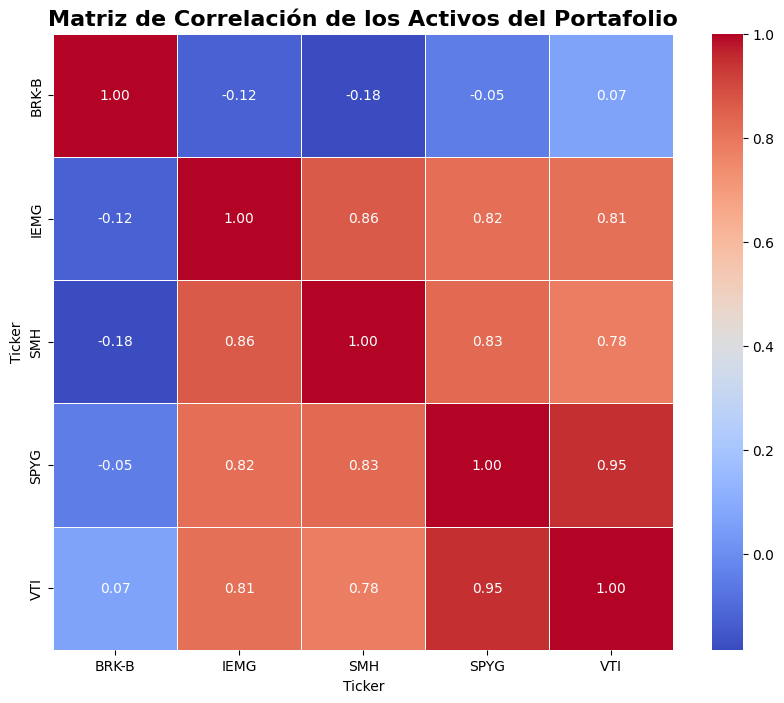

In [24]:
# 9. Mostrar la Matriz de Correlación de los Activos

# Calcular la matriz de correlación de los retornos diarios de los activos
correlation_matrix = retornos_activos.corr()

# Crear un mapa de calor para visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de los Activos del Portafolio', fontsize=16, fontweight='bold')
plt.show()